In [1]:

# finance_economics_dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('C:/Users/Admin/Downloads/finance_economics_dataset.csv',encoding='latin-1')

In [5]:
df.head()

,Date,Stock Index,Open Price,Close Price,Daily High,Daily Low,Trading Volume,GDP Growth (%),Inflation Rate (%),Unemployment Rate (%),...,Forex USD/EUR,Forex USD/JPY,Crude Oil Price (USD per Barrel),Gold Price (USD per Ounce),Real Estate Index,Retail Sales (Billion USD),Bankruptcy Rate (%),Mergers & Acquisitions Deals,Venture Capital Funding (Billion USD),Consumer Spending (Billion USD)
0,2000-01-01,Dow Jones,2128.75,2138.48,2143.70,2100.55,2670411,-0.37,6.06,6.10,...,1.04,119.87,47.20,1052.34,390.23,2229,2.12,3,76.64,4589
1,2000-01-02,S&P 500,2046.82,2036.18,2082.83,2009.53,690220415,3.19,4.95,6.62,...,1.00,98.22,52.84,1957.73,346.23,4156,1.40,21,5.67,10101
2,2000-01-03,Dow Jones,1987.92,1985.26,2022.28,1978.37,315284661,5.54,9.13,2.60,...,0.83,80.13,78.80,2339.49,439.46,340,0.79,48,39.43,13665
3,2000-01-04,Dow Jones,4625.02,4660.47,4665.26,4595.46,13098297,10.00,3.77,2.20,...,0.95,149.15,28.18,1308.54,213.07,8456,4.22,16,12.83,5192
4,2000-01-05,S&P 500,1998.18,1982.18,2044.31,1966.44,385306746,1.53,2.20,8.20,...,1.43,113.71,92.20,2210.08,405.49,1596,2.21,34,86.37,10688


In [6]:
# 1.  What is the shape of the dataset?

df.shape

(3000, 24)

In [7]:

# 2. What are the column names and their data types?

df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Date                                   3000 non-null   object 
 1   Stock Index                            3000 non-null   object 
 2   Open Price                             3000 non-null   float64
 3   Close Price                            3000 non-null   float64
 4   Daily High                             3000 non-null   float64
 5   Daily Low                              3000 non-null   float64
 6   Trading Volume                         3000 non-null   int64  
 7   GDP Growth (%)                         3000 non-null   float64
 8   Inflation Rate (%)                     3000 non-null   float64
 9   Unemployment Rate (%)                  3000 non-null   float64
 10  Interest Rate (%)                      3000 non-null   float64
 11  Cons

Date                                      object
Stock Index                               object
Open Price                               float64
Close Price                              float64
Daily High                               float64
Daily Low                                float64
Trading Volume                             int64
GDP Growth (%)                           float64
Inflation Rate (%)                       float64
Unemployment Rate (%)                    float64
Interest Rate (%)                        float64
Consumer Confidence Index                  int64
Government Debt (Billion USD)              int64
Corporate Profits (Billion USD)            int64
Forex USD/EUR                            float64
Forex USD/JPY                            float64
Crude Oil Price (USD per Barrel)         float64
Gold Price (USD per Ounce)               float64
Real Estate Index                        float64
Retail Sales (Billion USD)                 int64
Bankruptcy Rate (%) 

In [8]:

# 3. How many unique stock indices are there?

df['Stock Index'].unique()

array(['Dow Jones', 'S&P 500', 'NASDAQ'], dtype=object)

In [9]:

# 4.  What is the date range of the dataset?
df['Date'].min(), df['Date'].max()

('2000-01-01', '2008-03-18')

In [10]:

# 5. Are there any missing values?

df.isnull().sum()

Date                                     0
Stock Index                              0
Open Price                               0
Close Price                              0
Daily High                               0
Daily Low                                0
Trading Volume                           0
GDP Growth (%)                           0
Inflation Rate (%)                       0
Unemployment Rate (%)                    0
Interest Rate (%)                        0
Consumer Confidence Index                0
Government Debt (Billion USD)            0
Corporate Profits (Billion USD)          0
Forex USD/EUR                            0
Forex USD/JPY                            0
Crude Oil Price (USD per Barrel)         0
Gold Price (USD per Ounce)               0
Real Estate Index                        0
Retail Sales (Billion USD)               0
Bankruptcy Rate (%)                      0
Mergers & Acquisitions Deals             0
Venture Capital Funding (Billion USD)    0
Consumer Sp

In [11]:

# 6. Are there negative values in columns that should be non-negative?

(df.select_dtypes(include=['int64','float64']) < 0).sum()


Open Price                                 0
Close Price                                0
Daily High                                 0
Daily Low                                  0
Trading Volume                             0
GDP Growth (%)                           947
Inflation Rate (%)                         0
Unemployment Rate (%)                      0
Interest Rate (%)                          0
Consumer Confidence Index                  0
Government Debt (Billion USD)              0
Corporate Profits (Billion USD)            0
Forex USD/EUR                              0
Forex USD/JPY                              0
Crude Oil Price (USD per Barrel)           0
Gold Price (USD per Ounce)                 0
Real Estate Index                          0
Retail Sales (Billion USD)                 0
Bankruptcy Rate (%)                        0
Mergers & Acquisitions Deals               0
Venture Capital Funding (Billion USD)      0
Consumer Spending (Billion USD)            0
dtype: int

In [12]:

#7. What is the summary of GDP Growth (%)?
df['GDP Growth (%)'].describe()


count    3000.000000
mean        2.608903
std         4.287337
min        -5.000000
25%        -1.012500
50%         2.725000
75%         6.242500
max        10.000000
Name: GDP Growth (%), dtype: float64

In [13]:

# 8.  Are there rows with zero or near-zero trading volume?

# Count rows with exactly zero volume
(df['Trading Volume'] == 0).sum()

# Count rows with very low volume (example: less than 100)
(df['Trading Volume'] < 100).sum()


np.int64(0)

In [14]:
# 9. Are there any duplicate rows?

df.duplicated().sum()

np.int64(0)

In [15]:

# 10. Are there outliers in GDP, Gold, or Oil prices?

for col in ['GDP Growth (%)','Gold Price (USD per Ounce)','Crude Oil Price (USD per Barrel)']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(col, "Outliers:", outliers.shape[0])

GDP Growth (%) Outliers: 0
Gold Price (USD per Ounce) Outliers: 0
Crude Oil Price (USD per Barrel) Outliers: 0


In [16]:

# 11. What is the summary of Inflation Rate (%)?

df['Inflation Rate (%)'].describe()

count    3000.000000
mean        5.096830
std         2.910513
min         0.010000
25%         2.607500
50%         5.110000
75%         7.600000
max        10.000000
Name: Inflation Rate (%), dtype: float64

In [17]:

# 12. What is the average unemployment rate?

df['Unemployment Rate (%)'].mean()

np.float64(8.663786666666667)

In [18]:

# 13. Which index has the highest trading volume?

df.groupby('Stock Index')['Trading Volume'].sum().idxmax()

'S&P 500'

In [19]:

# 14.  How many stock records are from each index?

df['Stock Index'].value_counts()
     

Stock Index
S&P 500      1036
NASDAQ       1007
Dow Jones     957
Name: count, dtype: int64

In [20]:
# 15.  What is the correlation between inflation and interest rate?

df['Inflation Rate (%)'].corr(df['Interest Rate (%)'])

np.float64(0.005732927235576248)

In [21]:
# 16. What is the average Consumer Confidence Index?

df['Consumer Confidence Index'].mean()

np.float64(85.036)

In [22]:
# 17. Which column has the highest standard deviation?

df.std(numeric_only=True).idxmax()


'Trading Volume'

In [23]:
# 18. What is the highest gold price recorded?

df['Gold Price (USD per Ounce)'].max()

np.float64(2499.66)

In [24]:

# 19.  Which date had the highest crude oil price?

df.loc[df['Crude Oil Price (USD per Barrel)'].idxmax(), 'Date']

'2001-11-22'

In [25]:

# 20. What is the average corporate profit?

df['Corporate Profits (Billion USD)'].mean()

np.float64(2553.7563333333333)

In [26]:

# nsightful Analysis Questions

# 1.  What percentage of the dataset shows negative GDP growth?

negative_gdp = (df['GDP Growth (%)'] < 0).sum()
total = len(df)
percentage = (negative_gdp / total) * 100
print(f"{percentage:.2f}% of the dataset shows negative GDP growth")



31.57% of the dataset shows negative GDP growth


Correlation: 0.005732927235576248


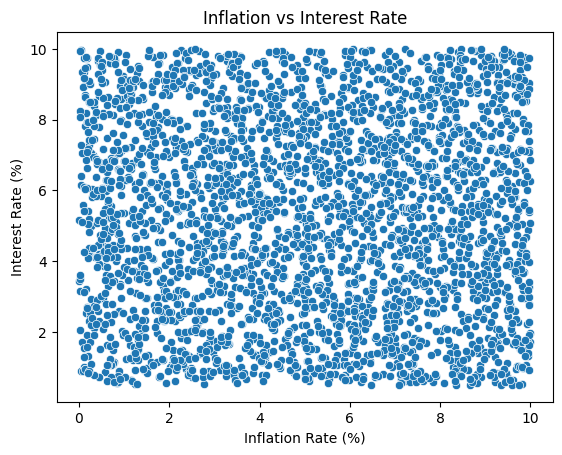

In [27]:

# 2. Does high inflation correspond to higher interest rates?

# Correlation value
corr = df['Inflation Rate (%)'].corr(df['Interest Rate (%)'])
print("Correlation:", corr)

# Scatterplot for relationship
sns.scatterplot(x='Inflation Rate (%)', y='Interest Rate (%)', data=df)
plt.title("Inflation vs Interest Rate")
plt.show()
     

Correlation: 0.018786001938759095


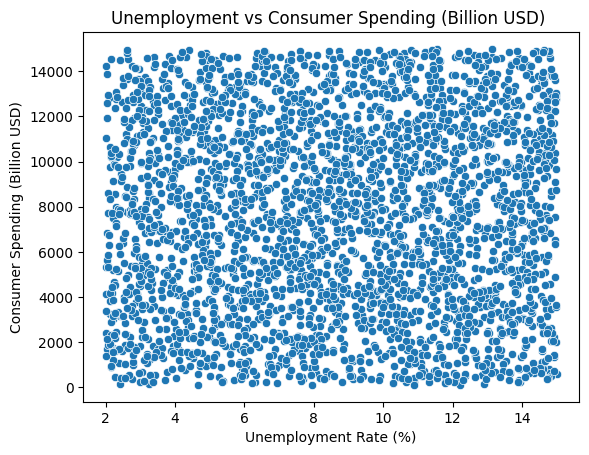

In [28]:

# 3.  Is there a relationship between unemployment and consumer spending?

# Correlation
corr = df['Unemployment Rate (%)'].corr(df['Consumer Spending (Billion USD)'])
print("Correlation:", corr)

# Scatterplot
sns.scatterplot(x='Unemployment Rate (%)', y='Consumer Spending (Billion USD)', data=df)
plt.title("Unemployment vs Consumer Spending (Billion USD) ")
plt.show()

Correlation: 0.01800805588826958


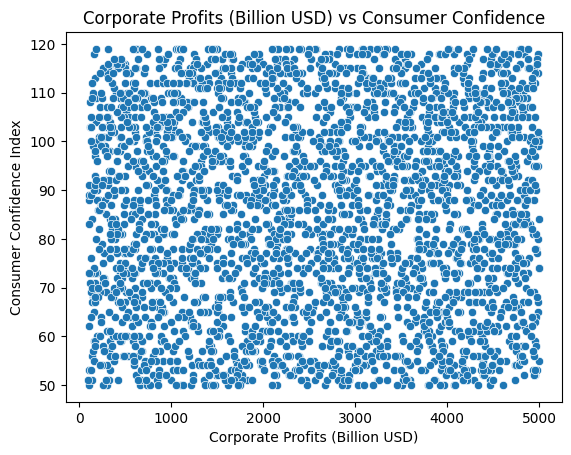

In [29]:

# 4.  Do higher corporate profits align with higher consumer confidence?

# Correlation
corr = df['Corporate Profits (Billion USD)'].corr(df['Consumer Confidence Index'])
print("Correlation:", corr)

# Scatterplot
sns.scatterplot(x='Corporate Profits (Billion USD)', y='Consumer Confidence Index', data=df)
plt.title("Corporate Profits (Billion USD) vs Consumer Confidence")
plt.show()


     

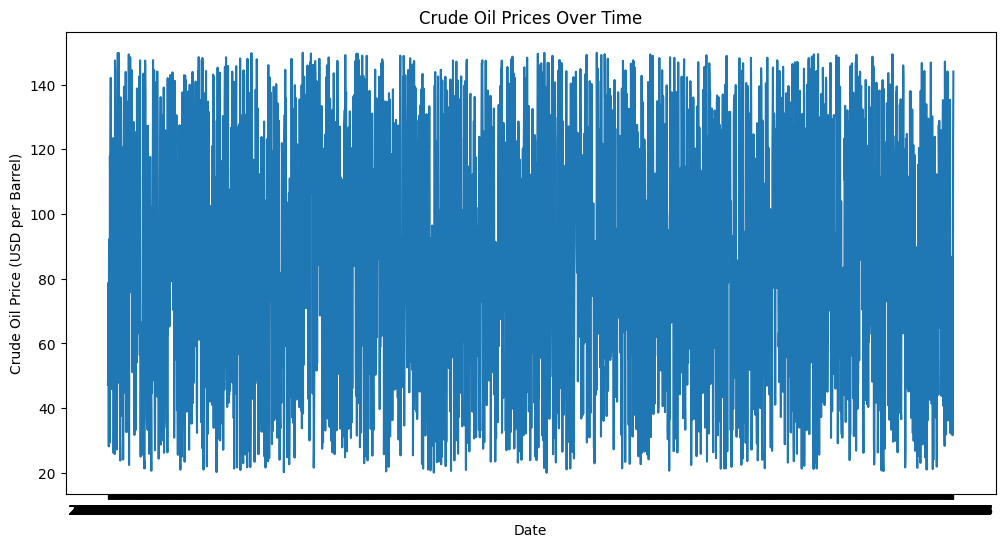

In [32]:
# 5. What’s the trend of crude oil prices over time?

# Line plot to visualize trend
plt.figure(figsize=(12,6))
sns.lineplot(x='Date', y='Crude Oil Price (USD per Barrel)', data=df)
plt.title("Crude Oil Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Crude Oil Price (USD per Barrel)")
plt.show()

Correlation (Gold vs Dow Jones Close Price): -0.010877070686967426


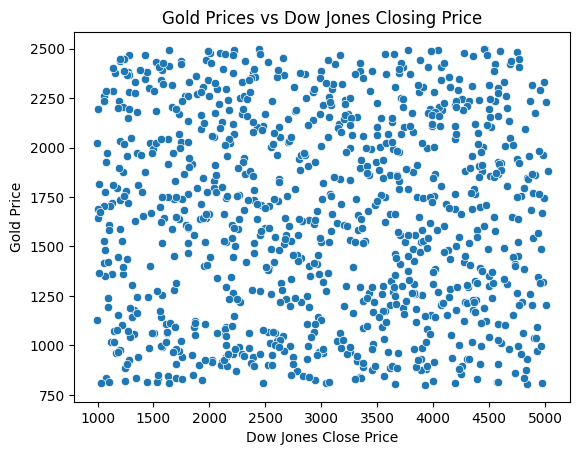

In [33]:
# 6. Are gold prices inversely related to stock performance?

# Filter data for Dow Jones
dow_df = df[df['Stock Index'] == 'Dow Jones']

# Correlation between Gold Price and Dow Jones Close Price
corr = dow_df['Gold Price (USD per Ounce)'].corr(dow_df['Close Price'])
print("Correlation (Gold vs Dow Jones Close Price):", corr)



sns.scatterplot(x='Close Price', y='Gold Price (USD per Ounce)', data=dow_df)
plt.title("Gold Prices vs Dow Jones Closing Price")
plt.xlabel("Dow Jones Close Price")
plt.ylabel("Gold Price")
plt.show()

Correlation (Government Debt vs Consumer Confidence): -0.03637006085825002


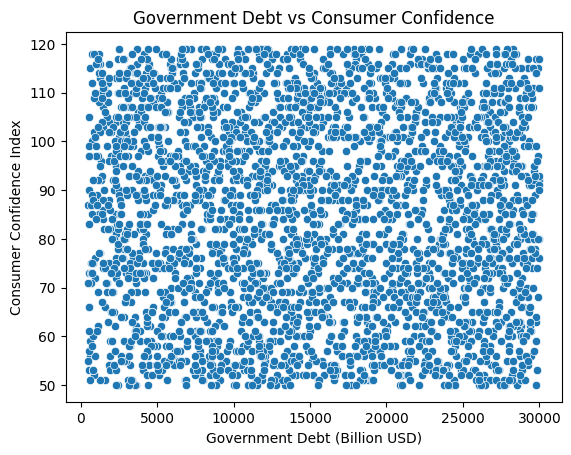

In [34]:

# 7. Does government debt impact consumer confidence?

# Correlation between Government Debt and Consumer Confidence
corr = df['Government Debt (Billion USD)'].corr(df['Consumer Confidence Index'])
print("Correlation (Government Debt vs Consumer Confidence):", corr)


sns.scatterplot(x='Government Debt (Billion USD)', y='Consumer Confidence Index', data=df)
plt.title("Government Debt vs Consumer Confidence")
plt.xlabel("Government Debt (Billion USD)")
plt.ylabel("Consumer Confidence Index")
plt.show()



Correlation (M&A Deals vs Dow Jones Close Price): -0.00010250146723386306


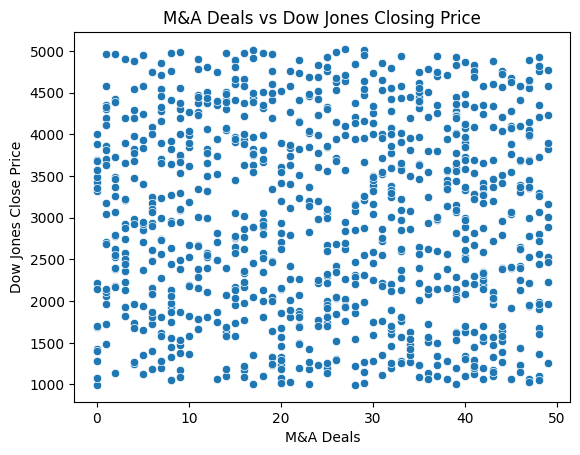

In [35]:

# 8. How do mergers & acquisitions (M&A) activity correlate with stock index closing prices?

# Filter Dow Jones
dow_df = df[df['Stock Index'] == 'Dow Jones']

# Correlation between M&A deals and Dow Jones closing price
corr = dow_df['Mergers & Acquisitions Deals'].corr(dow_df['Close Price'])
print("Correlation (M&A Deals vs Dow Jones Close Price):", corr)


sns.scatterplot(x='Mergers & Acquisitions Deals', y='Close Price', data=dow_df)
plt.title("M&A Deals vs Dow Jones Closing Price")
plt.xlabel("M&A Deals")
plt.ylabel("Dow Jones Close Price")
plt.show()


Correlation (GDP Growth vs Retail Sales): -0.014287611445719921


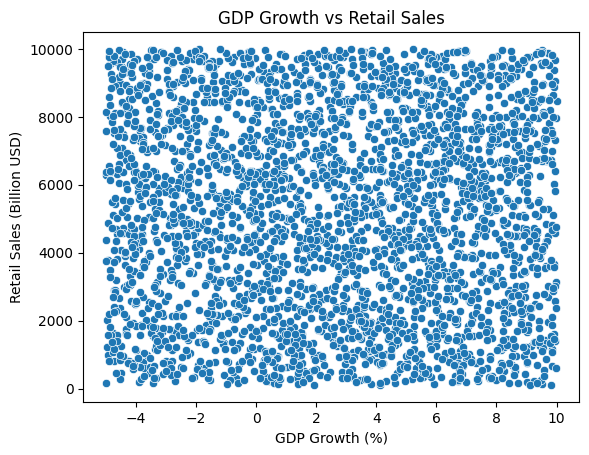

In [36]:
# 9. Is retail sales growth associated with GDP growth?

# Correlation between GDP Growth and Retail Sales
corr = df['GDP Growth (%)'].corr(df['Retail Sales (Billion USD)'])
print("Correlation (GDP Growth vs Retail Sales):", corr)

sns.scatterplot(x='GDP Growth (%)', y='Retail Sales (Billion USD)', data=df)
plt.title("GDP Growth vs Retail Sales")
plt.xlabel("GDP Growth (%)")
plt.ylabel("Retail Sales (Billion USD)")
plt.show()



Correlation (Dow Jones Close Price vs Consumer Spending): 0.025410580560942378


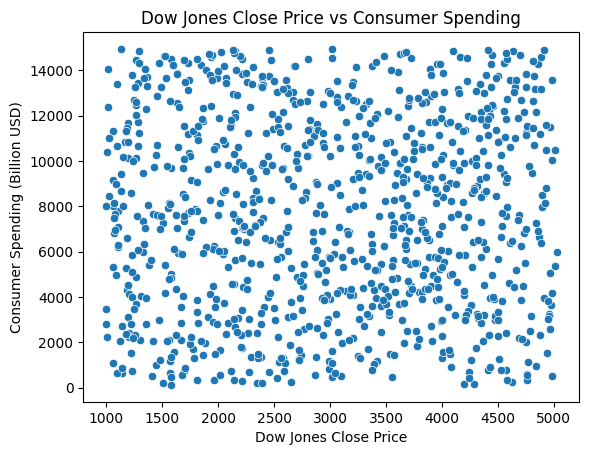

In [37]:
# 10. Is stock market performance linked to consumer spending?

# Filter Dow Jones
dow_df = df[df['Stock Index'] == 'Dow Jones']

# Correlation between Dow Jones Close Price and Consumer Spending
corr = dow_df['Close Price'].corr(dow_df['Consumer Spending (Billion USD)'])
print("Correlation (Dow Jones Close Price vs Consumer Spending):", corr)


sns.scatterplot(x='Close Price', y='Consumer Spending (Billion USD)', data=dow_df)
plt.title("Dow Jones Close Price vs Consumer Spending")
plt.xlabel("Dow Jones Close Price")
plt.ylabel("Consumer Spending (Billion USD)")
plt.show()



In [38]:
# 11. Which stock index had the highest average closing price?

# Average closing price per Stock Index
avg_close_per_index = df.groupby('Stock Index')['Close Price'].mean()

# Stock Index with highest average closing price
highest_index = avg_close_per_index.idxmax()
highest_avg_close = avg_close_per_index.max()

print(f"The stock index with the highest average closing price is {highest_index} (${highest_avg_close:.2f})")



The stock index with the highest average closing price is Dow Jones ($3004.46)


Correlation (Interest Rate vs Unemployment Rate): 0.018004072130972763


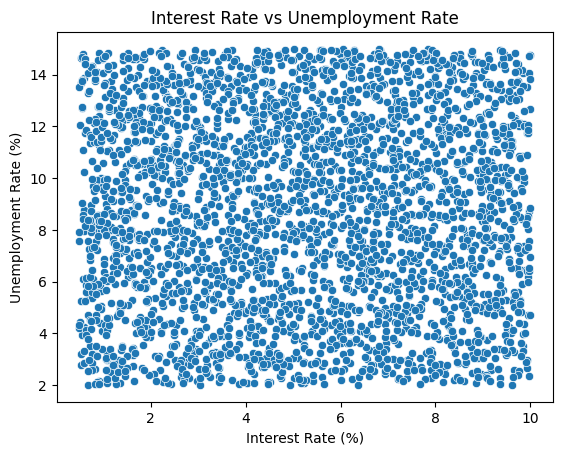

In [39]:
# 12. What is the relationship between interest rate and unemployment?

# Correlation between Interest Rate and Unemployment Rate
corr = df['Interest Rate (%)'].corr(df['Unemployment Rate (%)'])
print("Correlation (Interest Rate vs Unemployment Rate):", corr)


sns.scatterplot(x='Interest Rate (%)', y='Unemployment Rate (%)', data=df)
plt.title("Interest Rate vs Unemployment Rate")
plt.xlabel("Interest Rate (%)")
plt.ylabel("Unemployment Rate (%)")
plt.show()




Correlation (Consumer Confidence vs Bankruptcy Rate): -0.01631304347909407


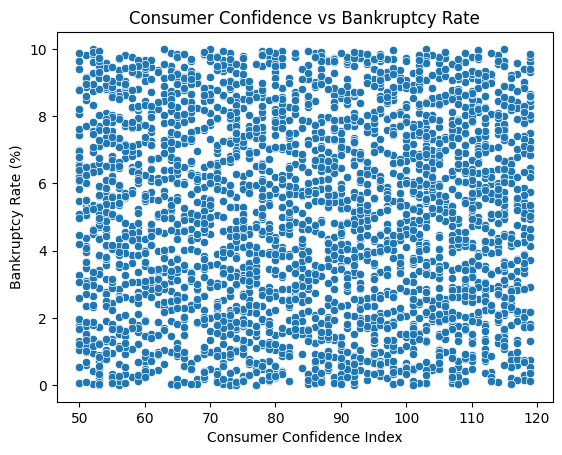

In [40]:
# 13. Do lower consumer confidence values coincide with higher bankruptcy rates?

# Correlation between Consumer Confidence and Bankruptcy Rate
corr = df['Consumer Confidence Index'].corr(df['Bankruptcy Rate (%)'])
print("Correlation (Consumer Confidence vs Bankruptcy Rate):", corr)


sns.scatterplot(x='Consumer Confidence Index', y='Bankruptcy Rate (%)', data=df)
plt.title("Consumer Confidence vs Bankruptcy Rate")
plt.xlabel("Consumer Confidence Index")
plt.ylabel("Bankruptcy Rate (%)")
plt.show()


In [41]:

# 14.  Which indicator has the highest correlation with stock close price?

# Select numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Compute correlations with Close Price
correlations = df[numeric_cols].corr()['Close Price'].drop('Close Price')

# Find the indicator with the highest absolute correlation
highest_corr_indicator = correlations.abs().idxmax()
highest_corr_value = correlations[highest_corr_indicator]

print(f"The indicator with the highest correlation with Close Price is {highest_corr_indicator} ({highest_corr_value:.2f})")

   

The indicator with the highest correlation with Close Price is Daily High (1.00)


Correlation (Corporate Profits vs Unemployment Rate): 0.00829241418823554


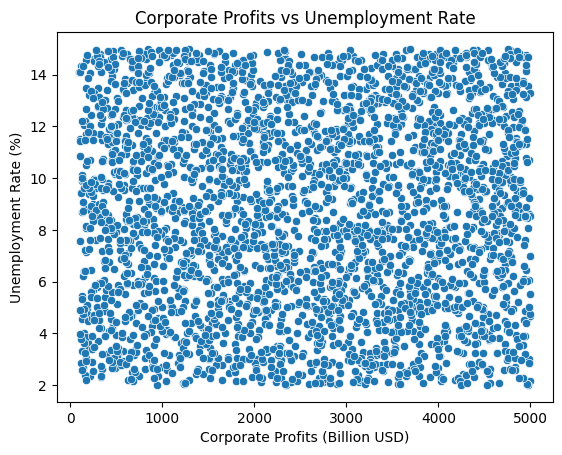

In [42]:
# 15.  Are unemployment rates lower when corporate profits are high?

# Correlation between Corporate Profits and Unemployment Rate
corr = df['Corporate Profits (Billion USD)'].corr(df['Unemployment Rate (%)'])
print("Correlation (Corporate Profits vs Unemployment Rate):", corr)


sns.scatterplot(x='Corporate Profits (Billion USD)', y='Unemployment Rate (%)', data=df)
plt.title("Corporate Profits vs Unemployment Rate")
plt.xlabel("Corporate Profits (Billion USD)")
plt.ylabel("Unemployment Rate (%)")
plt.show()



In [43]:

# Assessment 2:  Retail Sales Analysis

In [44]:
df=pd.read_csv('C:/Users/Admin/Downloads/Retail Data.csv',encoding='latin-1')

In [45]:
df.head()

,ï»¿Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Cost Price,Retail Price,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total
0,4293-1,02-09-2014,Vivek Sundaresam,"152 Bunnerong Road,Eastgardens",Sydney,NSW,Small Business,Tina Carlton,Critical,UGen Ultra Professional Cordless Optical Suite,...,$156.50,$300.97,$144.47,23.0,"$4,533.52",2%,$194.83,"$4,757.22",$7.18,"$4,291.55"
1,5001-1,24-10-2015,Shahid Hopkins,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Medium,Bagged Rubber Bands,...,$0.24,$1.26,$1.02,8.0,$45.20,3%,$0.00,$45.90,$0.70,$46.91
2,5004-1,13-03-2014,Dennis Pardue,"412 Brunswick St,Fitzroy",Melbourne,VIC,Consumer,Connor Betts,Not Specified,TechSavi Cordless Navigator Duo,...,$42.11,$80.98,$38.87,45.0,$873.32,4%,$72.23,$837.57,$7.18,$82.58
3,5009-1,18-02-2013,Sean Wendt,"145 Ramsay St,Haberfield",Sydney,NSW,Small Business,Phoebe Gour,Critical,Artisan Printable Repositionable Plastic Tabs,...,$5.33,$8.60,$3.27,16.0,$73.52,1%,$4.35,$740.67,$6.19,$730.92
4,5010-1,13-09-2014,Christina Vanderzanden,"188 Pitt Street,Sydney",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Pizazz Drawing Pencil Set,...,$1.53,$2.78,$1.25,49.0,$138.46,7%,$5.95,$123.77,$1.34,$125.97


In [46]:

# 1. View the structure of the dataset (columns, types, missing values).

# Count missing values per column
missing_values = df.isnull().sum()
print(missing_values)


ï»¿Order No          0
Order Date           0
Customer Name        0
Address              1
City                 0
State                0
Customer Type        0
Account Manager      0
Order Priority       0
Product Name         0
Product Category     0
Product Container    0
Ship Mode            0
Ship Date            0
Cost Price           0
Retail Price         0
Profit Margin        0
Order Quantity       1
Sub Total            0
Discount %           0
Discount $           0
Order Total          0
Shipping Cost        0
Total                0
dtype: int64


In [47]:

# Summary statistics for numeric columns
df.describe()

,Order Quantity
count,4999.000000
mean,26.483097
std,14.391863
min,1.000000
25%,13.000000
50%,27.000000
75%,39.000000
max,50.000000


In [48]:
# 2. What is the shape (rows, columns) of the dataset?

# Number of rows and columns
print("Shape of the dataset:", df.shape)


Shape of the dataset: (5000, 24)


In [49]:
# 3. Are there any duplicate records?\

# View the actual duplicate rows
duplicates = df[df.duplicated()]
print(duplicates)


Empty DataFrame
Columns: [ï»¿Order No, Order Date, Customer Name, Address, City, State, Customer Type, Account Manager, Order Priority, Product Name, Product Category, Product Container, Ship Mode, Ship Date, Cost Price, Retail Price, Profit Margin, Order Quantity, Sub Total, Discount %, Discount $, Order Total, Shipping Cost, Total]
Index: []

[0 rows x 24 columns]


In [50]:
# 4.  Are there any missing or corrupted entries in Ship Date, Order Date, or numeric columns?

# Check missing values for specific columns
missing_values = df[['Order Date', 'Ship Date', 'Cost Price', 'Retail Price',
                     'Profit Margin', 'Order Quantity', 'Sub Total', 'Discount %',
                     'Order Total', 'Shipping Cost']].isnull().sum()

print("Missing values per column:\n", missing_values)


Missing values per column:
 Order Date        0
Ship Date         0
Cost Price        0
Retail Price      0
Profit Margin     0
Order Quantity    1
Sub Total         0
Discount %        0
Order Total       0
Shipping Cost     0
dtype: int64


In [51]:

# 5.  Convert Order Date and Ship Date to datetime.

import pandas as pd

# Convert to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

# Check data types
print(df[['Order Date', 'Ship Date']].dtypes)

# Preview first 5 rows
print(df[['Order Date', 'Ship Date']].head())

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object
  Order Date  Ship Date
0 2014-02-09 2014-04-09
1        NaT        NaT
2        NaT        NaT
3        NaT        NaT
4        NaT        NaT


In [52]:

# 6.  Check for future or inconsistent shipping dates.

# Shipping date before order date
inconsistent_dates = df[df['Ship Date'] < df['Order Date']]
print("Orders with Ship Date earlier than Order Date:", inconsistent_dates.shape[0])

Orders with Ship Date earlier than Order Date: 24


In [53]:
# 7.  Convert price columns to numeric (remove $ and commas).
price_cols = ['Cost Price', 'Retail Price', 'Profit Margin', 'Sub Total',
              'Discount $', 'Order Total', 'Shipping Cost', 'Total']

for col in price_cols:
    # Convert to string first, then remove $ and commas, then convert to float
    df[col] = pd.to_numeric(df[col].astype(str).str.replace('$','', regex=False)
                                       .str.replace(',','', regex=False), errors='coerce')

print(df[price_cols].dtypes)
print(df[price_cols].head())



Cost Price       float64
Retail Price     float64
Profit Margin    float64
Sub Total        float64
Discount $       float64
Order Total      float64
Shipping Cost    float64
Total            float64
dtype: object
   Cost Price  Retail Price  Profit Margin  Sub Total  Discount $  \
0      156.50        300.97         144.47    4533.52      194.83   
1        0.24          1.26           1.02      45.20        0.00   
2       42.11         80.98          38.87     873.32       72.23   
3        5.33          8.60           3.27      73.52        4.35   
4        1.53          2.78           1.25     138.46        5.95   

   Order Total  Shipping Cost    Total  
0      4757.22           7.18  4291.55  
1        45.90           0.70    46.91  
2       837.57           7.18    82.58  
3       740.67           6.19   730.92  
4       123.77           1.34   125.97  


In [54]:
# 8. What are the unique values in Customer Type and Order Priority?

unique_customer_types = df['Customer Type'].unique()
print("Unique Customer Types:", unique_customer_types)

unique_order_priorities = df['Order Priority'].unique()
print("Unique Order Priorities:", unique_order_priorities)


Unique Customer Types: ['Small Business' 'Corporate' 'Consumer' 'Home Office']
Unique Order Priorities: ['Critical' 'Medium' 'Not Specified' 'Low' 'High']


In [55]:
# 9. What are the most common shipping modes?
# Count orders per shipping mode
shipping_counts = df['Ship Mode'].value_counts()
print("Shipping mode counts:\n", shipping_counts)

most_common_mode = shipping_counts.idxmax()
most_common_count = shipping_counts.max()
print(f"Most common shipping mode: {most_common_mode} ({most_common_count} orders)")

Shipping mode counts:
 Ship Mode
Regular Air       4236
Express Air        647
Delivery Truck     117
Name: count, dtype: int64
Most common shipping mode: Regular Air (4236 orders)


In [56]:

# 10. Which cities have the highest number of orders?

# Count orders per city
city_counts = df['City'].value_counts()
print("Number of orders per city:\n", city_counts)

top_city = city_counts.idxmax()
top_orders = city_counts.max()
print(f"City with the highest number of orders: {top_city} ({top_orders} orders)")

Number of orders per city:
 City
Sydney       3584
Melbourne    1416
Name: count, dtype: int64
City with the highest number of orders: Sydney (3584 orders)


In [57]:

# 11. What’s the range of order quantities and prices?

min_qty = df['Order Quantity'].min()
max_qty = df['Order Quantity'].max()
print(f"Order Quantity ranges from {min_qty} to {max_qty}")

price_cols = ['Cost Price', 'Retail Price', 'Profit Margin', 'Order Total', 'Shipping Cost']

for col in price_cols:
    min_price = df[col].min()
    max_price = df[col].max()
    print(f"{col} ranges from ${min_price:.2f} to ${max_price:.2f}")

Order Quantity ranges from 1.0 to 50.0
Cost Price ranges from $0.24 to $377.99
Retail Price ranges from $1.14 to $599.99
Profit Margin ranges from $0.36 to $430.18
Order Total ranges from $1.71 to $28299.51
Shipping Cost ranges from $0.49 to $69.30


In [58]:
# 12. Create a new column for shipping duration.

import pandas as pd

# Step 1: Clean column names (remove spaces and BOM characters)
df.columns = df.columns.str.strip().str.replace('ï»¿', '', regex=False)

# Step 2: Ensure Order Date and Ship Date are datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

# Step 3: Create a new column for shipping duration in days
df['Shipping Duration (days)'] = (df['Ship Date'] - df['Order Date']).dt.days

# Step 4: Preview the first 5 rows
print(df[['Order No', 'Order Date', 'Ship Date', 'Shipping Duration (days)']].head())

# Optional: check how many durations are missing (NaT)
print("Missing durations:", df['Shipping Duration (days)'].isnull().sum())


  Order No Order Date  Ship Date  Shipping Duration (days)
0   4293-1 2014-02-09 2014-04-09                      59.0
1   5001-1        NaT        NaT                       NaN
2   5004-1        NaT        NaT                       NaN
3   5009-1        NaT        NaT                       NaN
4   5010-1        NaT        NaT                       NaN
Missing durations: 3463


In [59]:

# 13. Are there any orders with zero or negative total or quantity?

# Ensure numeric columns are properly numeric
numeric_cols = ['Order Quantity', 'Order Total']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Filter rows with zero or negative values
zero_or_negative_orders = df[(df['Order Quantity'] <= 0) | (df['Order Total'] <= 0)]

# Show the results
print("Orders with zero or negative quantity or total:")
print(zero_or_negative_orders[['Order No', 'Order Quantity', 'Order Total']])

# Count how many
print("Number of problematic orders:", zero_or_negative_orders.shape[0])

Orders with zero or negative quantity or total:
Empty DataFrame
Columns: [Order No, Order Quantity, Order Total]
Index: []
Number of problematic orders: 0


In [60]:

# 14. Are all discount percentages matching discount dollar amounts?

# Ensure numeric columns are numeric
df['Discount %'] = pd.to_numeric(df['Discount %'], errors='coerce')
df['Discount $'] = pd.to_numeric(df['Discount $'], errors='coerce')
df['Sub Total'] = pd.to_numeric(df['Sub Total'], errors='coerce')

# Calculate expected discount in dollars
df['Expected Discount $'] = (df['Discount %'] / 100) * df['Sub Total']

# Check where the actual discount differs significantly from expected
mismatch = df[abs(df['Discount $'] - df['Expected Discount $']) > 0.01]  # Allowing small rounding difference

print("Orders where discount % does not match discount $:")
print(mismatch[['Order No', 'Discount %', 'Sub Total', 'Discount $', 'Expected Discount $']])

print("Number of mismatches:", mismatch.shape[0])

Orders where discount % does not match discount $:
Empty DataFrame
Columns: [Order No, Discount %, Sub Total, Discount $, Expected Discount $]
Index: []
Number of mismatches: 0


In [61]:
# 15.  Check for mismatches in total calculation’

# Step 1: Remove BOM from column names
df.columns = df.columns.str.replace('ï»¿', '', regex=False).str.strip()

# Step 2: Convert relevant columns to numeric
numeric_cols = ['Sub Total', 'Discount $', 'Shipping Cost', 'Total']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Step 3: Calculate expected total
df['Expected Total'] = df['Sub Total'] - df['Discount $'] + df['Shipping Cost']

# Step 4: Find mismatches (allow small rounding tolerance)
total_mismatch = df[abs(df['Total'] - df['Expected Total']) > 0.01]

# Step 5: Display mismatched rows
print("Orders where Total does not match calculation:")
print(total_mismatch[['Order No','Sub Total','Discount $','Shipping Cost','Total','Expected Total']])

print("Number of mismatches:", total_mismatch.shape[0])


Orders where Total does not match calculation:
     Order No  Sub Total  Discount $  Shipping Cost    Total  Expected Total
0      4293-1    4533.52      194.83           7.18  4291.55         4345.87
1      5001-1      45.20        0.00           0.70    46.91           45.90
2      5004-1     873.32       72.23           7.18    82.58          808.27
3      5009-1      73.52        4.35           6.19   730.92           75.36
4      5010-1     138.46        5.95           1.34   125.97          133.85
...       ...        ...         ...            ...      ...             ...
4995   6831-1     115.40       10.81           0.83   101.22          105.42
4996   6847-1    1999.69      143.91          19.51  1052.55         1875.29
4997   6922-1     929.40       27.88           1.99   921.03          903.51
4998   6939-1      66.54        4.46           0.50    64.27           62.58
4999   6980-1     213.34        4.67           5.01   221.52          213.68

[3960 rows x 6 columns]
Numb

In [62]:
# 16.  Identify top 5 products by order quantity.

# Ensure 'Order Quantity' is numeric
df['Order Quantity'] = pd.to_numeric(df['Order Quantity'], errors='coerce')

# Group by Product Name and sum the quantities
product_quantity = df.groupby('Product Name')['Order Quantity'].sum()

# Sort descending and get top 5
top5_products = product_quantity.sort_values(ascending=False).head(5)

print("Top 5 products by order quantity:")
print(top5_products)

Top 5 products by order quantity:
Product Name
Artisan 474 Labels                         3395.0
Smiths General Use 3-Ring Binders          3220.0
Artisan 479 Labels                         3039.0
Artisan 481 Labels                         2996.0
Apex Preferred Stainless Steel Scissors    2896.0
Name: Order Quantity, dtype: float64


In [63]:
# 17. Which Account Manager handled the most revenue?

# Ensure 'Total' is numeric
df['Total'] = pd.to_numeric(df['Total'], errors='coerce')

# Group by Account Manager and sum the total revenue
manager_revenue = df.groupby('Account Manager')['Total'].sum()

# Get the Account Manager with the highest revenue
top_manager = manager_revenue.idxmax()
top_revenue = manager_revenue.max()

print(f"The Account Manager with the highest revenue is {top_manager} with ${top_revenue:.2f}")

The Account Manager with the highest revenue is Connor Betts with $671173.17


In [64]:
# 18.  What is the average shipping cost by mode?

# Ensure 'Shipping Cost' is numeric
df['Shipping Cost'] = pd.to_numeric(df['Shipping Cost'], errors='coerce')

# Group by Ship Mode and calculate average shipping cost
avg_shipping = df.groupby('Ship Mode')['Shipping Cost'].mean().sort_values()

print("Average Shipping Cost by Mode:")
print(avg_shipping)


Average Shipping Cost by Mode:
Ship Mode
Express Air       5.247311
Delivery Truck    5.270085
Regular Air       5.503553
Name: Shipping Cost, dtype: float64


In [65]:
# 19. Find the most profitable product.

# Ensure 'Profit Margin' is numeric
df['Profit Margin'] = pd.to_numeric(df['Profit Margin'], errors='coerce')

# Group by Product Name and sum the profit
profit_per_product = df.groupby('Product Name')['Profit Margin'].sum()

# Find the most profitable product
most_profitable_product = profit_per_product.idxmax()
highest_profit = profit_per_product.max()

print(f"The most profitable product is '{most_profitable_product}' with a total profit of ${highest_profit:.2f}")



The most profitable product is 'Cando PC940 Copier' with a total profit of $17585.76


In [66]:
# 20. Find the most profitable product.

# Ensure 'Profit Margin' is numeric
df['Profit Margin'] = pd.to_numeric(df['Profit Margin'], errors='coerce')

# Group by Product Name and sum the profits
profit_per_product = df.groupby('Product Name')['Profit Margin'].sum()

# Get the most profitable product
most_profitable_product = profit_per_product.idxmax()
highest_profit = profit_per_product.max()

print(f"The most profitable product is '{most_profitable_product}' with a total profit of ${highest_profit:.2f}")

The most profitable product is 'Cando PC940 Copier' with a total profit of $17585.76


In [67]:

# Insightful Analysis Questions

# 1. What is the total revenue generated across all orders?

# Total revenue
total_revenue = df['Total'].sum()
print(f"Total revenue across all orders: ${total_revenue:,.2f}")

Total revenue across all orders: $3,731,536.40


In [68]:
# 2. Which customer type generates more revenue?

# Total revenue by Customer Type
revenue_by_customer = df.groupby('Customer Type')['Total'].sum().sort_values(ascending=False)
print(revenue_by_customer)

# Customer type with highest revenue
top_customer_type = revenue_by_customer.idxmax()
top_revenue = revenue_by_customer.max()
print(f"The customer type generating the most revenue is '{top_customer_type}' with ${top_revenue:,.2f}")

     

Customer Type
Corporate         1373796.44
Home Office        851621.96
Small Business     830886.35
Consumer           675231.65
Name: Total, dtype: float64
The customer type generating the most revenue is 'Corporate' with $1,373,796.44


Order Priority
Not Specified    817844.66
High             794199.00
Medium           784744.63
Critical         694547.97
Low              640200.14
Name: Total, dtype: float64


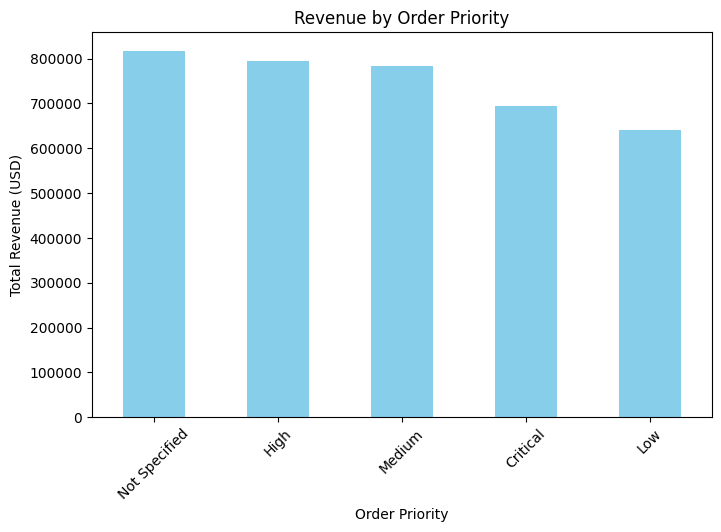

In [69]:
# 3.  How does order priority affect revenue?

# Total revenue by Order Priority
revenue_by_priority = df.groupby('Order Priority')['Total'].sum().sort_values(ascending=False)
print(revenue_by_priority)


revenue_by_priority.plot(kind='bar', color='skyblue', figsize=(8,5))
plt.title("Revenue by Order Priority")
plt.xlabel("Order Priority")
plt.ylabel("Total Revenue (USD)")
plt.xticks(rotation=45)
plt.show()


Product Category
Technology         20.423208
Office Supplies    17.682609
Furniture          12.701953
Name: Profit Margin, dtype: float64


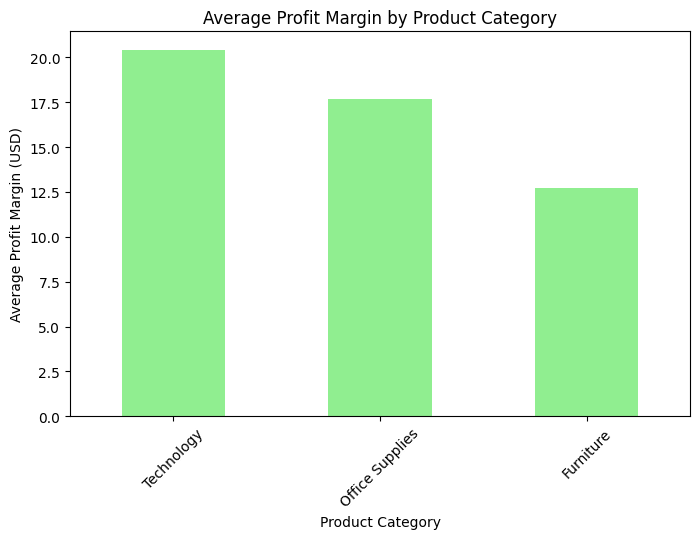

In [70]:
# 4. What is the average profit margin by product category?

# Average profit margin by product category
avg_profit_by_category = df.groupby('Product Category')['Profit Margin'].mean().sort_values(ascending=False)
print(avg_profit_by_category)


avg_profit_by_category.plot(kind='bar', color='lightgreen', figsize=(8,5))
plt.title("Average Profit Margin by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Profit Margin (USD)")
plt.xticks(rotation=45)
plt.show()


The most profitable product is 'Cando PC940 Copier' with a total profit of $17585.76


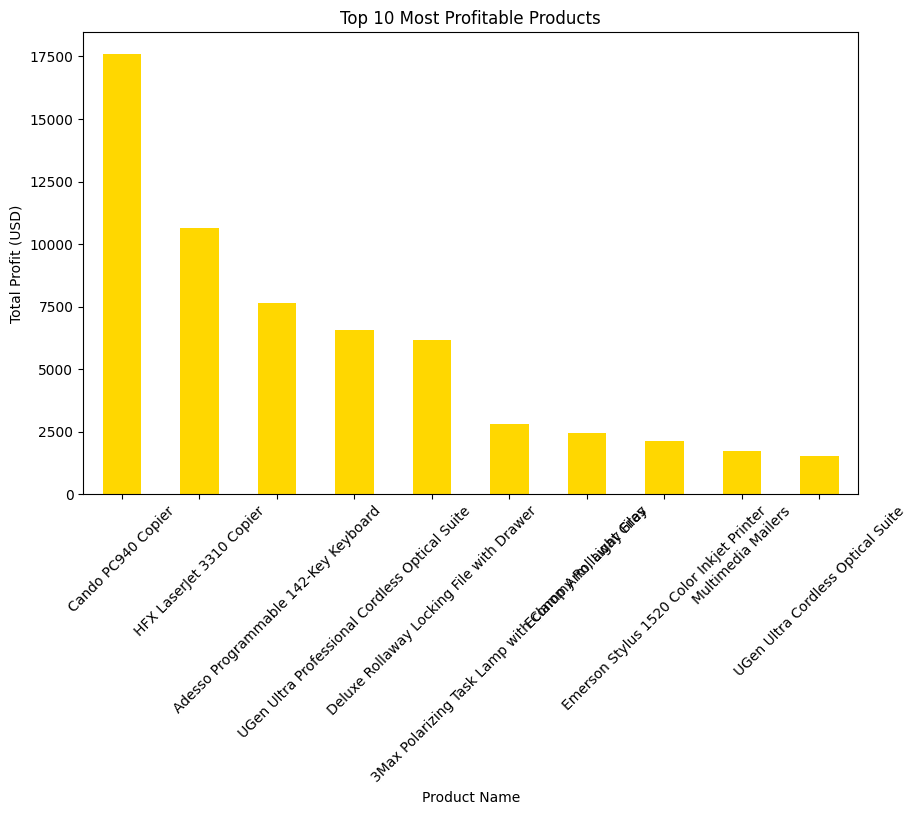

In [71]:

# 5. What is the most profitable product overall?

# If 'Profit Margin' represents profit per order, sum it per product
total_profit_per_product = df.groupby('Product Name')['Profit Margin'].sum()

# Most profitable product
most_profitable_product = total_profit_per_product.idxmax()
highest_profit = total_profit_per_product.max()

print(f"The most profitable product is '{most_profitable_product}' with a total profit of ${highest_profit:.2f}")

# Optional: visualize top 10 profitable products
top10_products = total_profit_per_product.sort_values(ascending=False).head(10)
top10_products.plot(kind='bar', color='gold', figsize=(10,6))
plt.title("Top 10 Most Profitable Products")
plt.xlabel("Product Name")
plt.ylabel("Total Profit (USD)")
plt.xticks(rotation=45)
plt.show()


Average shipping duration: 50.47 days
Median shipping duration: 59.00 days
Shortest shipping duration: -335.0 days
Longest shipping duration: 394.0 days


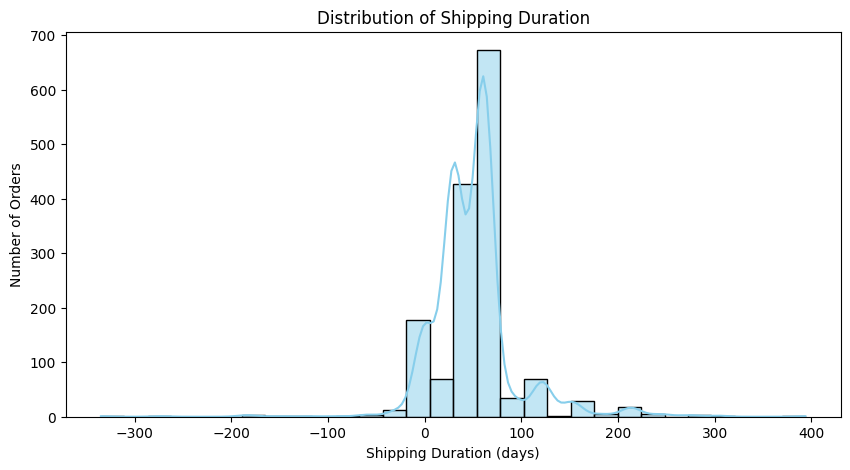

In [72]:

# 6. How many days does it usually take to ship an order?

# Shipping duration statistics
mean_days = df['Shipping Duration (days)'].mean()
median_days = df['Shipping Duration (days)'].median()
min_days = df['Shipping Duration (days)'].min()
max_days = df['Shipping Duration (days)'].max()

print(f"Average shipping duration: {mean_days:.2f} days")
print(f"Median shipping duration: {median_days:.2f} days")
print(f"Shortest shipping duration: {min_days} days")
print(f"Longest shipping duration: {max_days} days")

# Optional: visualize the distribution
plt.figure(figsize=(10,5))
sns.histplot(df['Shipping Duration (days)'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Shipping Duration")
plt.xlabel("Shipping Duration (days)")
plt.ylabel("Number of Orders")
plt.show()

     

Correlation (Shipping Duration vs Profit Margin): -0.03


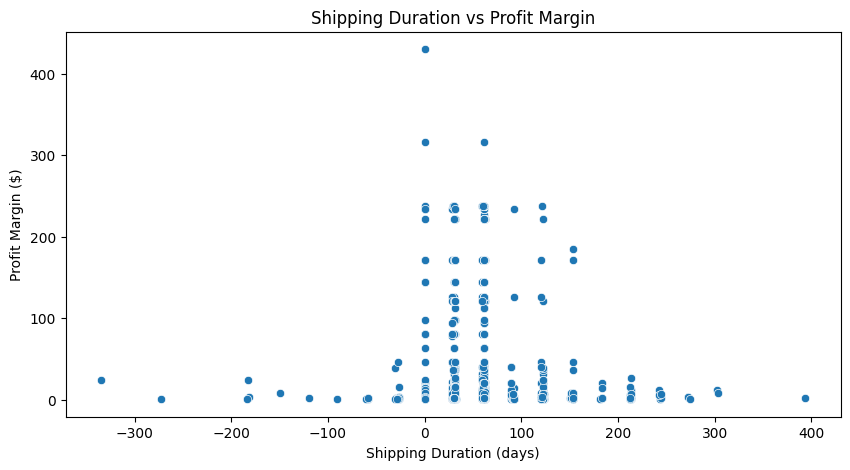

In [73]:
# 7. Do longer shipping times impact profit margins?

# Correlation between shipping duration and profit margin
corr = df['Shipping Duration (days)'].corr(df['Profit Margin'])
print(f"Correlation (Shipping Duration vs Profit Margin): {corr:.2f}")

# Scatter plot to visualize the relationship
plt.figure(figsize=(10,5))
sns.scatterplot(x='Shipping Duration (days)', y='Profit Margin', data=df)
plt.title("Shipping Duration vs Profit Margin")
plt.xlabel("Shipping Duration (days)")
plt.ylabel("Profit Margin ($)")
plt.show()

  

In [74]:

# 8. Which city brings in the highest revenue?

# Group by City and sum the Total revenue
revenue_by_city = df.groupby('City')['Total'].sum().sort_values(ascending=False)

# Display revenue by city
print(revenue_by_city)

# City with the highest revenue
top_city = revenue_by_city.idxmax()
top_revenue = revenue_by_city.max()
print(f"The city with the highest revenue is {top_city} with ${top_revenue:,.2f}")

     

City
Sydney       2678780.33
Melbourne    1052756.07
Name: Total, dtype: float64
The city with the highest revenue is Sydney with $2,678,780.33


In [75]:
# 9. Which account manager generated the most revenue?

# Group by Account Manager and sum revenue
revenue_by_manager = df.groupby('Account Manager')['Total'].sum().sort_values(ascending=False)

# Display revenue by account manager
print(revenue_by_manager)

# Account Manager with the highest revenue
top_manager = revenue_by_manager.idxmax()
top_revenue = revenue_by_manager.max()
print(f"The Account Manager who generated the most revenue is {top_manager} with ${top_revenue:,.2f}")


Account Manager
Connor Betts          671173.17
Tina Carlton          453891.62
Yvette Biti           379687.12
Nicholas Fernandes    305927.88
Mihael Khan           281948.64
Samantha Chairs       273750.35
Phoebe Gour           249340.81
Natasha Song          242718.26
Aanya Zhang           241344.03
Leighton Forrest      216736.14
Preston Senome        199052.07
Charlie Bui           138153.12
Radhya Staples         61519.53
Stevie Bacata          15879.22
Eanya Zhang              240.69
Oanya Zhang               73.57
Simantha Chairs           55.12
Wicholas Fernandes        39.99
Charlie Buo                5.07
Name: Total, dtype: float64
The Account Manager who generated the most revenue is Connor Betts with $671,173.17


In [76]:

# 10.  Which shipping mode is most cost-effective (lowest avg. shipping)?

# Calculate average shipping cost per shipping mode
avg_shipping_cost = df.groupby('Ship Mode')['Shipping Cost'].mean().sort_values()

print("Average shipping cost by mode:")
print(avg_shipping_cost)

# Most cost-effective mode
most_cost_effective = avg_shipping_cost.idxmin()
lowest_cost = avg_shipping_cost.min()
print(f"The most cost-effective shipping mode is '{most_cost_effective}' with an average cost of ${lowest_cost:.2f}")

  

Average shipping cost by mode:
Ship Mode
Express Air       5.247311
Delivery Truck    5.270085
Regular Air       5.503553
Name: Shipping Cost, dtype: float64
The most cost-effective shipping mode is 'Express Air' with an average cost of $5.25


Correlation (Discount % vs Profit Margin): nan


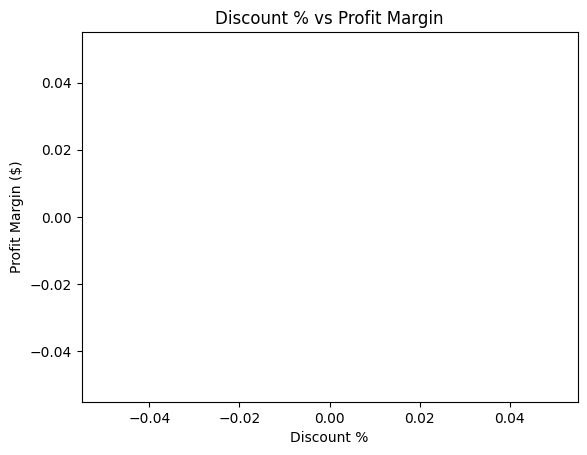

In [83]:
# 11.  Do higher discounts reduce profits?

# Correlation between Discount % and Profit Margin
corr = df['Discount %'].corr(df['Profit Margin'])
print("Correlation (Discount % vs Profit Margin):", corr)


sns.scatterplot(x='Discount %', y='Profit Margin', data=df)
plt.title("Discount % vs Profit Margin")
plt.xlabel("Discount %")
plt.ylabel("Profit Margin ($)")
plt.show()




State
NSW    3584
VIC    1416
Name: count, dtype: int64
State with the highest number of orders: NSW (3584 orders)


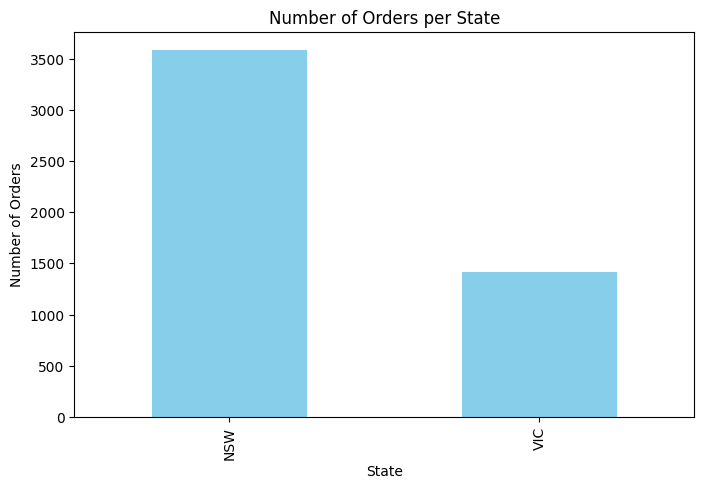

In [79]:
# 12. Which state has the highest number of orders?

# Count of orders per state
state_counts = df['State'].value_counts()
print(state_counts)

# State with the highest number of orders
top_state = state_counts.idxmax()
top_orders = state_counts.max()
print(f"State with the highest number of orders: {top_state} ({top_orders} orders)")


state_counts.plot(kind='bar', figsize=(8,5), color='skyblue')
plt.title("Number of Orders per State")
plt.xlabel("State")
plt.ylabel("Number of Orders")
plt.show()


The average discount across all orders is nan%


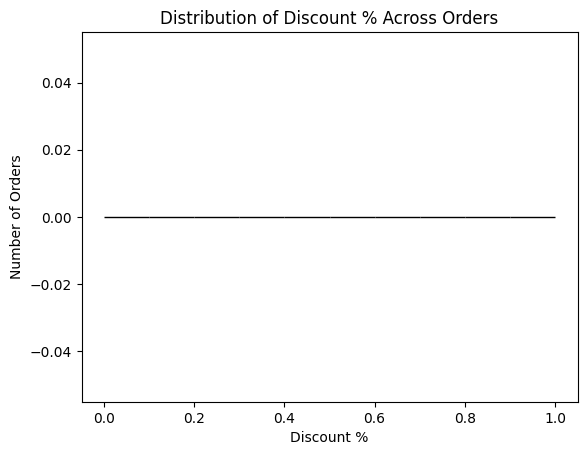

In [84]:

# 13. What is the average discount % across all orders?

# Ensure Discount % is numeric
df['Discount %'] = pd.to_numeric(df['Discount %'], errors='coerce')

# Calculate average discount %
avg_discount = df['Discount %'].mean()
print(f"The average discount across all orders is {avg_discount:.2f}%")


sns.histplot(df['Discount %'], bins=10, kde=True, color='skyblue')
plt.title("Distribution of Discount % Across Orders")
plt.xlabel("Discount %")
plt.ylabel("Number of Orders")
plt.show()

     

The average total spend per order is $746.31


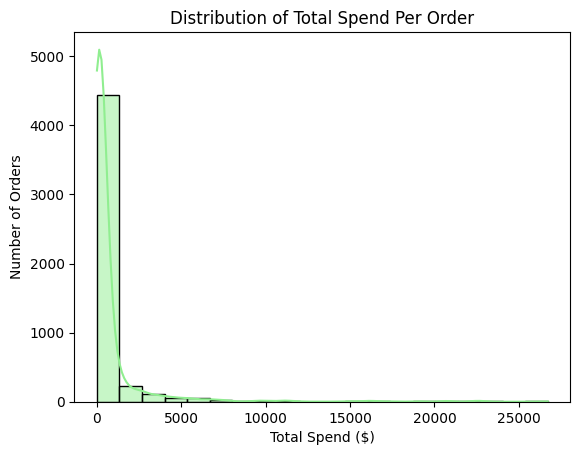

In [85]:
# 14. What is the average total spend per order?

# Ensure 'Total' column is numeric
df['Total'] = pd.to_numeric(df['Total'], errors='coerce')

# Calculate average total spend per order
avg_total_spend = df['Total'].mean()
print(f"The average total spend per order is ${avg_total_spend:.2f}")

sns.histplot(df['Total'], bins=20, kde=True, color='lightgreen')
plt.title("Distribution of Total Spend Per Order")
plt.xlabel("Total Spend ($)")
plt.ylabel("Number of Orders")
plt.show()


     